# 01 GBDT training

# 02 CV result

In [2]:
import os
import pandas as pd
for type in ['nor','ext','hr']:
    work_folder = r'E:\seoul\480_based\Machine Learning'
    folder = os.path.join(work_folder, rf'0_9394_GBDT_{type}_2023_cv_results.xlsx')

    file = pd.read_excel(folder)

    # 找到 rank_test_score 最小值
    min_value = file['rank_test_score'].min()

    # 打印最小值所在行
    min_row = file.loc[file['rank_test_score'] == min_value]
    print(min_row['mean_test_score'])


88    0.953392
Name: mean_test_score, dtype: float64
88    0.950838
Name: mean_test_score, dtype: float64
129    0.883492
Name: mean_test_score, dtype: float64


In [3]:
# 我已经有很多cv的结果了
# 200row 100column结果 -> R²
# 20个随机数。然后去看这个随机结果是什么？
import os
import pandas as pd
work_folder = r'E:\seoul\480_based\Machine Learning'
folder = os.path.join(work_folder, r'2023 GBDT_Random_Search_Results_0_9394.xlsx')
file = pd.read_excel(folder)
file

,GridSize,Target,Feature,Random seed,FeatureImportance_TrainModel,Train_R2,Train_RMSE,Test_R2,Test_RMSE,learning_rate,max_depth,max_features,min_samples_split,n_estimators,subsample
0,480,nor_2023,BCR,9394,0.3462,0.9999,0.0390,0.9559,0.8518,0.013651,5,0.602176,2,4168,0.563425
1,480,nor_2023,BHV,9394,0.0646,0.9999,0.0390,0.9559,0.8518,0.013651,5,0.602176,2,4168,0.563425
2,480,nor_2023,SVF,9394,0.0321,0.9999,0.0390,0.9559,0.8518,0.013651,5,0.602176,2,4168,0.563425
3,480,nor_2023,NDVI,9394,0.1983,0.9999,0.0390,0.9559,0.8518,0.013651,5,0.602176,2,4168,0.563425
4,480,nor_2023,EV,9394,0.1279,0.9999,0.0390,0.9559,0.8518,0.013651,5,0.602176,2,4168,0.563425
5,480,nor_2023,WR,9394,0.1106,0.9999,0.0390,0.9559,0.8518,0.013651,5,0.602176,2,4168,0.563425
6,480,nor_2023,Dist_W,9394,0.0287,0.9999,0.0390,0.9559,0.8518,0.013651,5,0.602176,2,4168,0.563425
7,480,nor_2023,Dist_P,9394,0.0160,0.9999,0.0390,0.9559,0.8518,0.013651,5,0.602176,2,4168,0.563425
8,480,nor_2023,Dist_M,9394,0.0390,0.9999,0.0390,0.9559,0.8518,0.013651,5,0.602176,2,4168,0.563425
9,480,nor_2023,X,9394,0.0205,0.9999,0.0390,0.9559,0.8518,0.013651,5,0.602176,2,4168,0.563425


# feature importance 出图

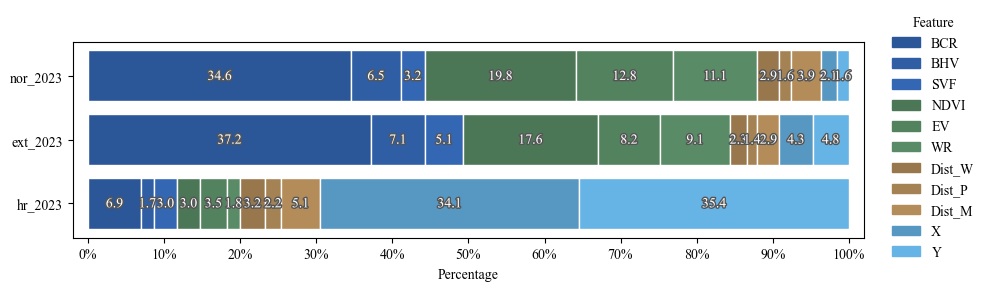

Saved to: E:\seoul\480_based\Machine Learning\2023_final_GBDT_feature_importance_stacked.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import hsv_to_rgb

# 设置全局字体为 Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

# 读数据
path = r"E:\seoul\480_based\Machine Learning\2023 GBDT_Random_Search_Results_0_9394.xlsx"
df = pd.read_excel(path)

# pivot：每行一个 Target，每列一个 Feature
pivot = df.pivot_table(index='Target', columns='Feature', 
                       values='FeatureImportance_TrainModel', aggfunc='sum').fillna(0)


# 手动调整 Target 的行顺序
row_order = ['hr_2023', 'ext_2023','nor_2023']
pivot = pivot.reindex(row_order)

# 指定 Feature 顺序
explanatory_vars_gbdt = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 
                         'Dist_W', 'Dist_P', 'Dist_M', 'X', 'Y']


# 四组特征
groups = {
    'group1': ['BCR', 'BHV', 'SVF'],          # 湖蓝系
    'group2': ['NDVI', 'EV', 'WR'],           # 藏蓝系
    'group3': ['Dist_W', 'Dist_P', 'Dist_M'], # 棕色系
    'group4': ['X', 'Y']                      # 墨绿色系
}

base_colors = {
    'group4': np.array([0.4, 0.7, 0.9]),   # 柔和湖蓝
    'group1': np.array([0.2, 0.4, 0.7]),   # 深藏蓝
    'group2': np.array([0.35, 0.55, 0.4]), # 墨绿色
    'group3': np.array([0.7, 0.55, 0.35])# 高级咖啡棕}
 } 
# 生成组内渐变色（浅→深）
def generate_gradient_colors(features, base_rgb):
    n = len(features)
    colors = []
    for i in range(n):
        factor = 0.85 + 0.15*(i/(n-1))  # 浅→深
        colors.append(base_rgb * factor)
    return dict(zip(features, colors))

color_map = {}
for gname, feats in groups.items():
    color_map.update(generate_gradient_colors(feats, base_colors[gname]))

# 绘图
fig, ax = plt.subplots(figsize=(10, max(3, 0.8 * len(pivot))))
bottom = np.zeros(len(pivot))
# 绘图前设置 X 轴范围和刻度
ax.set_xlim(-0.02, 1.02)  # 超过 1 点点空间

# 设置 X 轴刻度为百分比
ax.set_xticks(np.linspace(0, 1, 11))  # 0,0.1,...,1
ax.set_xticklabels([f"{int(x*100)}%" for x in np.linspace(0, 1, 11)])

for feature in explanatory_vars_gbdt:
    vals = pivot[feature].values
    ax.barh(pivot.index, vals, left=bottom, color=color_map[feature], edgecolor='white')
    for i, val in enumerate(vals):
        txt = ax.text(
            bottom[i] + val/2, i, f"{val*100:.1f}", 
            va='center', ha='center', fontsize=10, color="white"
        )
        # 给文字加描边
        txt.set_path_effects([
            path_effects.Stroke(linewidth=2, foreground='#555555'),  # 描边颜色
            path_effects.Normal()  # 正常文字显示
        ])
    bottom += vals

# legend
handles = [plt.Rectangle((0,0),1,1,color=color_map[feature]) for feature in explanatory_vars_gbdt]
ax.legend(handles, explanatory_vars_gbdt, bbox_to_anchor=(1.02, 1.2), loc='upper left', title='Feature', frameon=False)

ax.set_xlabel("Percentage")

plt.tight_layout()
# 保存到本地（示例）
out_file = r"E:\seoul\480_based\Machine Learning\2023_final_GBDT_feature_importance_stacked.png"
fig.savefig(out_file, dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()
print("Saved to:", out_file)

# PDP

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
# 设置文件夹、变量
grid_folder = r'E:\seoul\480_based'
output_fig_dir = r'E:\seoul\480_based\Machine Learning\figures\nonlinear_predictions_PDP_brute'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

years = [2023]

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\2023 GBDT_Random_Search_Results_0_9394.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdem = rf'{grid_folder}\statistics\SDEM_all_params.xlsx'
    best_df_sdem = pd.read_excel(best_params_file_sdem)

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()
    print(target_folder)

    for target in target_folder[1:]:

        # 先收集 EXT 和 NOR 的预测数据
        ext_targets = [t for t in target_folder if ('ext' in t.lower()) or ('nor' in t.lower())]
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- EXT + NOR 合并 ----------------
        for feature in explanatory_vars:
            plt.figure(figsize=(8,5))
            for target in ext_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)
                print(random_seeds[0])

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = random_seeds[0])
                model = GradientBoostingRegressor(**params_gbdt).fit(X_train, y_train)
                # ----------- PDP 计算部分 -----------
                pdp_result = partial_dependence(
                    model,
                    X_test,
                    [feature],
                    method = 'brute',
                    grid_resolution=100,
                    kind='average'
                )

                X_grid = pdp_result['values'][0]
                y_pdp_pred = pdp_result['average'][0]
                print(y_pdp_pred)

                # SDEM
                row_sdem = best_df_sdem[best_df_sdem['Target']==target].iloc[0]
                params_sdem = {
                    'CONSTANT': row_sdem['CONSTANT'],
                    'BCR': row_sdem['BCR'],
                    'BHV': row_sdem['BHV'],
                    'SVF': row_sdem['SVF'],
                    'NDVI': row_sdem['NDVI'],
                    'EV': row_sdem['EV'],
                    'WR': row_sdem['WR'],
                    'Dist_W': row_sdem['Dist_W'],
                    'Dist_P': row_sdem['Dist_P'],
                    'Dist_M': row_sdem['Dist_M'],
                    'W_BCR': row_sdem['W_BCR'],
                    'W_BHV': row_sdem['W_BHV'],
                    'W_SVF': row_sdem['W_SVF'],
                    'W_NDVI': row_sdem['W_NDVI'],
                    'W_EV': row_sdem['W_EV'],
                    'W_WR': row_sdem['W_WR'],
                    'lambda': row_sdem['lambda']
                }
                # SDEM 预测
                X_mean = gdf_clean[explanatory_vars].mean().to_dict()
                w = DistanceBand.from_dataframe(gdf_clean, threshold=1000, binary=False)
                w.transform = 'r'
                WX = lag_spatial(w, gdf_clean[explanatory_vars_clean].values)
                WX_mean = pd.Series(WX.mean(axis=0), index=[f"W_{v}" for v in explanatory_vars_clean])
                y_sdem_pred = []
                for val in X_grid:
                    X_temp = X_mean.copy()
                    X_temp[feature] = val
                    WX_temp = WX_mean.copy()
                    if feature in explanatory_vars_clean:
                        WX_temp[feature] = pd.Series(val, index=[f"W_{feature}"])
                    all_vars = {'CONSTANT': 1.0, **X_temp, **WX_temp.to_dict()}
                    y_pred = 0
                    for var, coef in params_sdem.items():
                        if var != 'lambda':
                            y_pred += coef * all_vars.get(var, 0)
                    y_sdem_pred.append(y_pred)
                y_sdem_pred = np.array(y_sdem_pred)

                # 根据 EXT/NOR 指定颜色
                if 'ext' in target.lower():
                    color_gbdt = '#333333'  # 黑色
                    color_sdem = '#555555'  # 黑色虚线
                else:  # NOR
                    color_gbdt = '#0000ff'  # 蓝色
                    color_sdem = '#0000ff'  # 蓝色虚线

                # 命名规范映射
                target_name_map = {
                    'nor_2023': 'Nor_LST',
                    'ext_2023': 'Ext_LST',
                    'hr_2023': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名
                # 绘图
                plt.plot(X_grid, y_pdp_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdem_pred, color=color_sdem, linestyle='--', linewidth=2, label=f'{label_name} SDEM')

            plt.xlabel(feature, fontsize=20)
            plt.ylabel('Temperature (℃)', fontsize=20)
            plt.grid(True)
            plt.legend()
            plt.ylim(20,55)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_ext_nor_{year}_comparison.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_ext_nor_{year}_comparison.png")

['nor_2023' 'ext_2023' 'hr_2023']
9394


E:\python\lib\site-packages\sklearn\utils\_bunch.py:35: FutureWarning: Key: 'values', is deprecated in 1.3 and will be removed in 1.5. Please use 'grid_values' instead.
  warnings.warn(
E:\python\lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
E:\python\lib\site-packages\libpysal\weights\weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  warnings.warn(message)


[36.43479128 36.48456131 36.60385237 36.73835669 36.70521572 36.76398485
 36.70486837 36.7075978  36.9106655  36.94598978 36.92288403 36.95884465
 36.99200284 37.0498742  37.45867537 37.4499255  37.45938658 37.4177685
 37.4006643  37.49526174 37.55609098 37.55706294 37.58052549 37.59562676
 37.59001367 37.60500488 37.64652569 37.72564431 37.75125251 37.75272204
 37.80215172 37.87038587 37.87393405 37.82787978 37.82223436 37.87051443
 37.92759463 37.97337528 38.00222704 38.00019497 37.99960914 38.00061489
 37.90463415 37.8992941  37.92533367 37.93718649 38.0012588  38.17858031
 38.40393374 38.24305241 38.28030539 38.27303371 38.26392267 38.23191037
 38.21773875 38.24084621 38.30941456 38.31123327 38.40953005 38.44211478
 38.4325579  38.44097634 38.45741169 38.44464937 38.4934936  38.47585273
 38.45035114 38.46594732 38.46607593 38.47462398 38.50853559 38.56089873
 38.53540185 38.50837769 38.51537623 38.53130911 38.5308508  38.54965078
 38.54453639 38.51984254 38.50280744 38.50164277 38.

E:\python\lib\site-packages\sklearn\utils\_bunch.py:35: FutureWarning: Key: 'values', is deprecated in 1.3 and will be removed in 1.5. Please use 'grid_values' instead.
  warnings.warn(
E:\python\lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
E:\python\lib\site-packages\libpysal\weights\weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  warnings.warn(message)


[41.06543144 41.12989395 41.23524664 41.26615007 41.19058675 41.30694817
 41.26256568 41.2715606  41.41427195 41.4475913  41.45210234 41.48115463
 41.56860215 41.58505535 41.86286086 41.90597295 41.93797707 41.90731666
 41.91759797 42.02737579 42.06530984 42.09679549 42.12073429 42.13166418
 42.11335534 42.12489216 42.13397137 42.26345426 42.3782446  42.3922589
 42.40545918 42.48145829 42.54142956 42.42200075 42.45724328 42.62057429
 42.80841422 42.87583771 42.90979559 42.88700321 42.86578092 42.80914053
 42.79364422 42.79586495 42.84049404 42.85887036 42.90101249 43.03541311
 43.11944734 43.05928148 43.08519684 43.07190119 43.01638425 43.00973695
 43.03105301 43.04444472 43.0749027  43.11269149 43.18564794 43.22933478
 43.19337698 43.18641047 43.18466291 43.16769608 43.40498107 43.42066823
 43.44535506 43.38037322 43.36759727 43.30255059 43.24833498 43.4630247
 43.41086167 43.34656304 43.39339089 43.39184515 43.39007085 43.41058211
 43.50773462 43.42819707 43.43346166 43.46546647 43.4

...

[37.11461388 37.24212297 37.40446252 37.43145023 37.47754516 37.46934717
 37.48758783 37.46733687 37.42708827 37.41958655 37.40982499 37.41107283
 37.41750703 37.39755339 37.45186763 37.43355013 37.42806768 37.38328449
 37.3966178  37.36583363 37.3372338  37.38489068 37.41035335 37.38046297
 37.38525621 37.37454525 37.37065592 37.37310664 37.38455922 37.379339
 37.33145278 37.37716128 37.45285995 37.42600944 37.43945259 37.39113059
 37.43301457 37.42069594 37.39660766 37.33272308 37.37322821 37.41219829
 37.47247044 37.42736084 37.45454043 37.48427782 37.45302791 37.45647705
 37.46119226 37.49140225 37.48788385 37.48765925 37.41805928 37.44533059
 37.47489277 37.46306235 37.46852199 37.46964991 37.48381468 37.47553502
 37.47131216 37.4650929  37.48345843 37.46803831 37.45434559 37.44230934
 37.43671003 37.42177092 37.40399584 37.40232249 37.4053977  37.40438049
 37.37670405 37.39672563 37.35537819 37.35982624 37.36427226 37.37258751
 37.37129139 37.36770894 37.36491451 37.35817032 37.3

E:\python\lib\site-packages\sklearn\utils\_bunch.py:35: FutureWarning: Key: 'values', is deprecated in 1.3 and will be removed in 1.5. Please use 'grid_values' instead.
  warnings.warn(


[42.10946308 42.14428469 42.19801897 42.28351438 42.30309072 42.22761141
 42.32865307 42.26039594 42.25818838 42.28612999 42.2505104  42.25474108
 42.25677283 42.26021938 42.29490876 42.2770424  42.27225557 42.24375592
 42.25285724 42.25269349 42.2591167  42.25568155 42.26353721 42.25197818
 42.26340799 42.24837464 42.2261318  42.21470339 42.17505181 42.18355865
 42.11256969 42.15888837 42.17372468 42.12712257 42.11722494 42.08994562
 42.13637199 42.16314389 42.15659359 42.12052931 42.07534419 42.05687429
 42.11928394 42.10110289 42.10452883 42.11947142 42.06890684 42.04295903
 42.0574146  42.04958493 42.06825495 42.05047952 41.92077395 41.92366714
 41.95878785 41.94828352 41.96573926 41.95328    41.95870481 41.9702769
 42.00034449 42.03610936 42.06677009 42.06045403 42.02123752 42.01770033
 41.99861975 41.99428687 41.95628764 41.95545506 41.95862609 41.93833922
 41.94801466 41.96047947 41.91190495 41.91049673 41.90882828 41.90001948
 41.89067566 41.8931356  41.89651451 41.88147303 41.

E:\python\lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
E:\python\lib\site-packages\libpysal\weights\weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  warnings.warn(message)


('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')
✅ Saved Dist_M_ext_nor_2023_comparison.png


# hr

In [2]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
# 设置文件夹、变量
grid_folder = r'E:\seoul\480_based'
output_fig_dir = r'E:\seoul\480_based\Machine Learning\figures\nonlinear_predictions_PDP_brute'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

years = [2023]

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\2023 GBDT_Random_Search_Results_0_9394.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdem = rf'{grid_folder}\statistics\SDEM_all_params.xlsx'
    best_df_sdem = pd.read_excel(best_params_file_sdem)

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()
    print(target_folder)

    for target in target_folder[2:]:
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- EXT + NOR 合并 ----------------
        for feature in explanatory_vars:
            plt.figure(figsize=(8,5))
            for target in hr_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = random_seeds[0])
                model = GradientBoostingRegressor(**params_gbdt).fit(X_train, y_train)
                # ----------- PDP 计算部分 -----------
                pdp_result = partial_dependence(
                    model,
                    X_test,
                    [feature],
                    method='brute',
                    grid_resolution=100,
                    kind='average'
                )

                X_grid = pdp_result['values'][0]
                y_pdp_pred = pdp_result['average'][0]
                print(y_pdp_pred)

                # SDEM
                row_sdem = best_df_sdem[best_df_sdem['Target']==target].iloc[0]
                params_sdem = {
                    'CONSTANT': row_sdem['CONSTANT'],
                    'BCR': row_sdem['BCR'],
                    'BHV': row_sdem['BHV'],
                    'SVF': row_sdem['SVF'],
                    'NDVI': row_sdem['NDVI'],
                    'EV': row_sdem['EV'],
                    'WR': row_sdem['WR'],
                    'Dist_W': row_sdem['Dist_W'],
                    'Dist_P': row_sdem['Dist_P'],
                    'Dist_M': row_sdem['Dist_M'],
                    'W_BCR': row_sdem['W_BCR'],
                    'W_BHV': row_sdem['W_BHV'],
                    'W_SVF': row_sdem['W_SVF'],
                    'W_NDVI': row_sdem['W_NDVI'],
                    'W_EV': row_sdem['W_EV'],
                    'W_WR': row_sdem['W_WR'],
                    'lambda': row_sdem['lambda']
                }
                # SDEM 预测
                X_mean = gdf_clean[explanatory_vars].mean().to_dict()
                w = DistanceBand.from_dataframe(gdf_clean, threshold=1000, binary=False)
                w.transform = 'r'
                WX = lag_spatial(w, gdf_clean[explanatory_vars_clean].values)
                WX_mean = pd.Series(WX.mean(axis=0), index=[f"W_{v}" for v in explanatory_vars_clean])
                y_sdem_pred = []
                for val in X_grid:
                    X_temp = X_mean.copy()
                    X_temp[feature] = val
                    WX_temp = WX_mean.copy()
                    if feature in explanatory_vars_clean:
                        WX_temp[feature] = pd.Series(val, index=[f"W_{feature}"])
                    all_vars = {'CONSTANT': 1.0, **X_temp, **WX_temp.to_dict()}
                    y_pred = 0
                    for var, coef in params_sdem.items():
                        if var != 'lambda':
                            y_pred += coef * all_vars.get(var, 0)
                    y_sdem_pred.append(y_pred)
                y_sdem_pred = np.array(y_sdem_pred)


                color_gbdt = '#333333'  # 黑色
                color_sdem = '#555555'  # 黑色虚线

                # 命名规范映射
                target_name_map = {
                    'nor_2023': 'Nor_LST',
                    'ext_2023': 'Ext_LST',
                    'hr_2023': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名
                # 绘图
                plt.plot(X_grid, y_pdp_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdem_pred, color=color_sdem, linestyle='--', linewidth=2, label=f'{label_name} SDEM')

            plt.xlabel(feature, fontsize=20)
            plt.ylabel('Temperature (℃)', fontsize=20)

            plt.grid(True)
            plt.legend()
            plt.ylim(-15,-1)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_hr_{year}_comparison.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_hr_{year}_comparison.png")

['nor_2023' 'ext_2023' 'hr_2023']


E:\python\lib\site-packages\sklearn\utils\_bunch.py:35: FutureWarning: Key: 'values', is deprecated in 1.3 and will be removed in 1.5. Please use 'grid_values' instead.
  warnings.warn(
E:\python\lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
E:\python\lib\site-packages\libpysal\weights\weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  warnings.warn(message)


[-4.65213546 -4.63796758 -4.63270839 -4.63082744 -4.62903205 -4.63392055
 -4.63956461 -4.63957429 -4.63441796 -4.63492441 -4.64431242 -4.64656886
 -4.64652759 -4.6478938  -4.66008089 -4.6645049  -4.6648142  -4.66355635
 -4.65437935 -4.66231137 -4.6654014  -4.67049443 -4.67457252 -4.67780116
 -4.67256761 -4.67294726 -4.67346942 -4.67797891 -4.68871806 -4.68825496
 -4.69160057 -4.69455257 -4.69076209 -4.69431983 -4.69189028 -4.69182225
 -4.69838691 -4.69731548 -4.70451157 -4.7043187  -4.69985166 -4.6893863
 -4.71056097 -4.71213701 -4.71403134 -4.71127269 -4.71109039 -4.71260575
 -4.71174537 -4.7144634  -4.7125057  -4.70536452 -4.69633207 -4.70539663
 -4.70907649 -4.72890676 -4.72988939 -4.74333756 -4.717262   -4.70721246
 -4.70224914 -4.70214048 -4.69062403 -4.67573744 -4.69616058 -4.72147281
 -4.71910224 -4.71252473 -4.69812061 -4.68311443 -4.67024534 -4.68962023
 -4.69134242 -4.6946792  -4.70379641 -4.6975545  -4.70082671 -4.69933674
 -4.70240424 -4.70346197 -4.70577553 -4.70686279 -4.

E:\python\lib\site-packages\sklearn\utils\_bunch.py:35: FutureWarning: Key: 'values', is deprecated in 1.3 and will be removed in 1.5. Please use 'grid_values' instead.
  warnings.warn(
E:\python\lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
E:\python\lib\site-packages\libpysal\weights\weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  warnings.warn(message)


[-4.74811555 -4.74769938 -4.74685167 -4.74826733 -4.74735667 -4.75210471
 -4.75178682 -4.74320966 -4.74233053 -4.73662002 -4.74261513 -4.74669568
 -4.74955061 -4.74960311 -4.74711159 -4.74093334 -4.74625735 -4.70860714
 -4.70296844 -4.71258648 -4.72065197 -4.72089024 -4.70567641 -4.70593292
 -4.69261457 -4.69418246 -4.69468751 -4.68818842 -4.69615939 -4.69427719
 -4.69248448 -4.6816083  -4.679417   -4.68913201 -4.68079792 -4.67853955
 -4.67442844 -4.67261595 -4.66714991 -4.66588227 -4.67121026 -4.67222108
 -4.67656953 -4.67803142 -4.68735766 -4.68774677 -4.68671355 -4.68776802
 -4.68334365 -4.67602725 -4.67623715 -4.67376129 -4.67166508 -4.67312053
 -4.6749199  -4.67071871 -4.67519689 -4.67983917 -4.66357559 -4.65648876
 -4.65055047 -4.64961304 -4.64917819 -4.64005597 -4.64211633 -4.64068289
 -4.64158012 -4.64216281 -4.64763871 -4.64298538 -4.64292984 -4.64640275
 -4.64546209 -4.64350074 -4.64104591 -4.64141319 -4.64228482 -4.64155503
 -4.63832451 -4.63723807 -4.63608234 -4.63491605 -4

...

('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')
✅ Saved Dist_W_hr_2023_comparison.png


E:\python\lib\site-packages\sklearn\utils\_bunch.py:35: FutureWarning: Key: 'values', is deprecated in 1.3 and will be removed in 1.5. Please use 'grid_values' instead.
  warnings.warn(
E:\python\lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
E:\python\lib\site-packages\libpysal\weights\weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  warnings.warn(message)


[-4.68741716 -4.72423456 -4.71925417 -4.71754588 -4.71668792 -4.71918949
 -4.72195176 -4.72558234 -4.72529513 -4.73070439 -4.73294583 -4.73319401
 -4.73391368 -4.73289671 -4.71458294 -4.71133062 -4.71409568 -4.71501448
 -4.72248795 -4.74366691 -4.73832877 -4.74597706 -4.74899668 -4.75390331
 -4.75275506 -4.74581622 -4.74274939 -4.73957352 -4.73372343 -4.72936823
 -4.72387649 -4.72031742 -4.72404509 -4.72246293 -4.71593555 -4.71249039
 -4.71578943 -4.71208525 -4.69364165 -4.70815787 -4.7111049  -4.72173989
 -4.72825561 -4.73322161 -4.7278177  -4.72046327 -4.71216578 -4.71343548
 -4.69998913 -4.70778811 -4.70911789 -4.70942391 -4.70773231 -4.70524781
 -4.7018647  -4.69664683 -4.69688501 -4.69802672 -4.69557289 -4.69412313
 -4.69193501 -4.68921127 -4.69036374 -4.69044772 -4.69025642 -4.68837026
 -4.6804166  -4.68014408 -4.66652309 -4.66628175 -4.66689826 -4.66668343
 -4.66373382 -4.66086173 -4.66046963 -4.66206316 -4.66231148 -4.66410822
 -4.66419318 -4.66402314 -4.66382806 -4.66339426 -4

E:\python\lib\site-packages\sklearn\utils\_bunch.py:35: FutureWarning: Key: 'values', is deprecated in 1.3 and will be removed in 1.5. Please use 'grid_values' instead.
  warnings.warn(
E:\python\lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
E:\python\lib\site-packages\libpysal\weights\weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  warnings.warn(message)


[-4.83100086 -4.83816544 -4.83159079 -4.83490799 -4.80785808 -4.8050624
 -4.83137423 -4.84648627 -4.85977578 -4.86387725 -4.86792744 -4.87199577
 -4.86468134 -4.87086946 -4.86855856 -4.86094805 -4.8645526  -4.87698422
 -4.86794724 -4.86235464 -4.86566221 -4.85857142 -4.85934181 -4.85993709
 -4.85073241 -4.84441059 -4.78741724 -4.74784216 -4.73734357 -4.73119215
 -4.71030294 -4.71150356 -4.69537864 -4.66946806 -4.66217632 -4.65579478
 -4.64820457 -4.6559495  -4.65699739 -4.6550906  -4.64464221 -4.63332641
 -4.59250397 -4.59347839 -4.5802554  -4.56323524 -4.55688723 -4.55202563
 -4.54979695 -4.53634331 -4.5141367  -4.50418736 -4.49833928 -4.48506784
 -4.47927804 -4.47843884 -4.47555192 -4.47133657 -4.44656583 -4.44666824
 -4.45280258 -4.45913344 -4.45717279 -4.45512159 -4.45634898 -4.45437104
 -4.45828148 -4.45913513 -4.45678775 -4.45426025 -4.4513198  -4.44966671
 -4.45704879 -4.45856832 -4.45745454 -4.45770564 -4.44726265 -4.44511914
 -4.44052106 -4.44214375 -4.44254084 -4.4420736  -4.

# ext+nor self

In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
# 设置文件夹、变量
grid_folder = r'E:\seoul\480_based'
output_fig_dir = r'E:\seoul\480_based\Machine Learning\figures\nonlinear_predictions_PDP_self'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

years = [2023]

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\2023 GBDT_Random_Search_Results_0_9394.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdem = rf'{grid_folder}\statistics\SDEM_all_params.xlsx'
    best_df_sdem = pd.read_excel(best_params_file_sdem)

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()
    print(target_folder)

    for target in target_folder[1:]:

        # 先收集 EXT 和 NOR 的预测数据
        ext_targets = [t for t in target_folder if ('ext' in t.lower()) or ('nor' in t.lower())]
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- EXT + NOR 合并 ----------------
        for feature in explanatory_vars:
            plt.figure(figsize=(8,5))
            for target in ext_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])
                # ----------- PDP 计算部分 -----------
                model = GradientBoostingRegressor(**params_gbdt)
                model.fit(X_train, y_train)

                X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
                X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns)
                X_base[feature] = X_grid

                y_gbdt_pred = model.predict(X_base)

                # SDEM
                row_sdem = best_df_sdem[best_df_sdem['Target']==target].iloc[0]
                params_sdem = {
                    'CONSTANT': row_sdem['CONSTANT'],
                    'BCR': row_sdem['BCR'],
                    'BHV': row_sdem['BHV'],
                    'SVF': row_sdem['SVF'],
                    'NDVI': row_sdem['NDVI'],
                    'EV': row_sdem['EV'],
                    'WR': row_sdem['WR'],
                    'Dist_W': row_sdem['Dist_W'],
                    'Dist_P': row_sdem['Dist_P'],
                    'Dist_M': row_sdem['Dist_M'],
                    'W_BCR': row_sdem['W_BCR'],
                    'W_BHV': row_sdem['W_BHV'],
                    'W_SVF': row_sdem['W_SVF'],
                    'W_NDVI': row_sdem['W_NDVI'],
                    'W_EV': row_sdem['W_EV'],
                    'W_WR': row_sdem['W_WR'],
                    'lambda': row_sdem['lambda']
                }
                # SDEM 预测
                X_mean = gdf_clean[explanatory_vars].mean().to_dict()
                w = DistanceBand.from_dataframe(gdf_clean, threshold=1000, binary=False)
                w.transform = 'r'
                WX = lag_spatial(w, gdf_clean[explanatory_vars_clean].values)
                WX_mean = pd.Series(WX.mean(axis=0), index=[f"W_{v}" for v in explanatory_vars_clean])
                y_sdem_pred = []
                for val in X_grid:
                    X_temp = X_mean.copy()
                    X_temp[feature] = val
                    WX_temp = WX_mean.copy()
                    if feature in explanatory_vars_clean:
                        WX_temp[feature] = pd.Series(val, index=[f"W_{feature}"])
                    all_vars = {'CONSTANT': 1.0, **X_temp, **WX_temp.to_dict()}
                    y_pred = 0
                    for var, coef in params_sdem.items():
                        if var != 'lambda':
                            y_pred += coef * all_vars.get(var, 0)
                    y_sdem_pred.append(y_pred)
                y_sdem_pred = np.array(y_sdem_pred)

                # 根据 EXT/NOR 指定颜色
                if 'ext' in target.lower():
                    color_gbdt = '#333333'  # 黑色
                    color_sdem = '#555555'  # 黑色虚线
                else:  # NOR
                    color_gbdt = '#0000ff'  # 蓝色
                    color_sdem = '#0000ff'  # 蓝色虚线

                # 命名规范映射
                target_name_map = {
                    'nor_2023': 'Nor_LST',
                    'ext_2023': 'Ext_LST',
                    'hr_2023': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名

                # 绘图
                plt.plot(X_grid, y_gbdt_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdem_pred, color=color_sdem, linestyle='--', linewidth=2, label=f'{label_name} SDEM')


            ax = plt.gca()  # 获取当前坐标轴
            percentiles = np.percentile(X[feature], np.linspace(10, 90, 9))  # 0%,10%,...,100%
            rug_height = 0.05  # 画布坐标高度（0~1）

            for p in percentiles:
                ax.plot([p, p], [0, rug_height], color='black', linewidth=1.2, transform=ax.get_xaxis_transform())
                # 绘制完 rug 后加这一行：
                ax.autoscale(enable=True, axis='x', tight=True)

            # 设置全局字体为 Times New Roman
            plt.rcParams["font.family"] = "Times New Roman"

            plt.xlabel(feature, fontsize=16)
            plt.ylabel('Temperature (℃)', fontsize=16)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(False)
            plt.legend(loc='upper right', frameon=False, fontsize=12)
            plt.xlim(X[feature].min(), X[feature].max())
            plt.ylim(20,55)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_ext_nor_{year}_comparison.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_ext_nor_{year}_comparison.png")

['nor_2023' 'ext_2023' 'hr_2023']


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(


('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(


('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')
✅ Saved BCR_ext_nor_2023_comparison.png


...

('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')
✅ Saved Dist_W_ext_nor_2023_comparison.png


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(


('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(


('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')
✅ Saved Dist_P_ext_nor_2023_comparison.png


# hr self

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
# 设置文件夹、变量
grid_folder = r'E:\seoul\480_based'
output_fig_dir = r'E:\seoul\480_based\Machine Learning\figures\nonlinear_predictions_PDP_self'
os.makedirs(output_fig_dir, exist_ok=True)
# 设置全局字体为 Times New Roman
plt.rcParams["font.family"] = "Times New Roman"
explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

years = [2023]

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\2023 GBDT_Random_Search_Results_0_9394.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdem = rf'{grid_folder}\statistics\SDEM_all_params.xlsx'
    best_df_sdem = pd.read_excel(best_params_file_sdem)
    best_df_sdem = best_df_sdem[best_df_sdem['Model']=='SDEM']
    
    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()
    print(target_folder)

    for target in target_folder[2:]:
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- EXT + NOR 合并 ----------------
        for feature in explanatory_vars:
            plt.figure(figsize=(8,5))
            for target in hr_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = random_seeds[0])
                model = GradientBoostingRegressor(**params_gbdt).fit(X_train, y_train)

                # ----------- PDP 计算部分 -----------
                model = GradientBoostingRegressor(**params_gbdt)
                model.fit(X_train, y_train)

                X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
                X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns)
                X_base[feature] = X_grid

                y_gbdt_pred = model.predict(X_base)


                # SDEM
                row_sdem = best_df_sdem[best_df_sdem['Target']==target].iloc[0]
                params_sdem = {
                    'CONSTANT': row_sdem['CONSTANT'],
                    'BCR': row_sdem['BCR'],
                    'BHV': row_sdem['BHV'],
                    'SVF': row_sdem['SVF'],
                    'NDVI': row_sdem['NDVI'],
                    'EV': row_sdem['EV'],
                    'WR': row_sdem['WR'],
                    'Dist_W': row_sdem['Dist_W'],
                    'Dist_P': row_sdem['Dist_P'],
                    'Dist_M': row_sdem['Dist_M'],
                    'W_BCR': row_sdem['W_BCR'],
                    'W_BHV': row_sdem['W_BHV'],
                    'W_SVF': row_sdem['W_SVF'],
                    'W_NDVI': row_sdem['W_NDVI'],
                    'W_EV': row_sdem['W_EV'],
                    'W_WR': row_sdem['W_WR'],
                    'lambda': row_sdem['lambda']
                }
                # SDEM 预测
                X_mean = gdf_clean[explanatory_vars].mean().to_dict()
                w = DistanceBand.from_dataframe(gdf_clean, threshold=1000, binary=False)
                w.transform = 'r'
                WX = lag_spatial(w, gdf_clean[explanatory_vars_clean].values)
                WX_mean = pd.Series(WX.mean(axis=0), index=[f"W_{v}" for v in explanatory_vars_clean])
                y_sdem_pred = []
                for val in X_grid:
                    X_temp = X_mean.copy()
                    X_temp[feature] = val
                    WX_temp = WX_mean.copy()
                    if feature in explanatory_vars_clean:
                        WX_temp[feature] = pd.Series(val, index=[f"W_{feature}"])
                    all_vars = {'CONSTANT': 1.0, **X_temp, **WX_temp.to_dict()}
                    y_pred = 0
                    for var, coef in params_sdem.items():
                        if var != 'lambda':
                            y_pred += coef * all_vars.get(var, 0)
                    y_sdem_pred.append(y_pred)
                y_sdem_pred = np.array(y_sdem_pred)


                color_gbdt = '#333333'  # 黑色
                color_sdem = '#555555'  # 黑色虚线

                # 命名规范映射
                target_name_map = {
                    'nor_2023': 'Nor_LST',
                    'ext_2023': 'Ext_LST',
                    'hr_2023': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名

                # 绘图
                plt.plot(X_grid, y_gbdt_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdem_pred, color=color_sdem, linestyle='--', linewidth=2, label=f'{label_name} SDEM')


            ax = plt.gca()  # 获取当前坐标轴
            percentiles = np.percentile(X[feature], np.linspace(10, 90, 9))  # 0%,10%,...,100%
            rug_height = 0.05  # 画布坐标高度（0~1）

            for p in percentiles:
                ax.plot([p, p], [0, rug_height], color='black', linewidth=1.2, transform=ax.get_xaxis_transform())

            # 设置全局字体为 Times New Roman
            plt.rcParams["font.family"] = "Times New Roman"

            plt.xlabel(feature, fontsize=16)
            plt.ylabel('Temperature (℃)', fontsize=16)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(False)
            plt.legend(loc='upper right', frameon=False, fontsize=12)
            plt.margins(x=0)  # 去掉x方向留白
            plt.ylim(-15,-1)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_hr_{year}_comparison.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_hr_{year}_comparison.png")

c:\Users\JUJUBE\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


['nor_2023' 'ext_2023' 'hr_2023']


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(


('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')
✅ Saved BCR_hr_2023_comparison.png


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(


...

('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')
✅ Saved Dist_W_hr_2023_comparison.png


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(


('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')
✅ Saved Dist_P_hr_2023_comparison.png


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(


('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')
✅ Saved Dist_M_hr_2023_comparison.png
